# Phase 1 — P&L Attribution & Concentration Analysis

**Sister notebook to:** `phase1_complete_reference.ipynb`
**Source data:** `results/ssd_core_trades.parquet` (12,255 trades) + `results/ssd_core_monthly.parquet` (251 months)

**The two questions this notebook answers:**

1. **Attribution** — where did our +86% total return come from?
   - Which trades?
   - Which pairs?
   - Which sectors?
   - Long-spread or short-spread bets?
   - Which years?
   - Quick reversions or long holds?

2. **Concentration** — is the P&L broadly diversified or carried by outliers?
   - What % of P&L comes from the top 1% / 5% / 10% of trades?
   - HHI (Herfindahl-Hirschman index)
   - Gini coefficient
   - Pair-level concentration

**Why this matters for the QF621 defense:** if 80% of return comes from 20 trades during
the 2008-09 crisis, the strategy is fragile — its Sharpe is high in this sample by luck
of timing. If P&L is broadly distributed, the strategy has economic content. The answer
also constrains *which improvements* would help most in Phase 2.

---

## Quick navigation
1. **[Setup](#1.-Setup)**
2. **[Trade-level distribution](#2.-Trade-level-distribution)**
3. **[Pareto / concentration analysis](#3.-Pareto-concentration-analysis)**
4. **[Pair-level attribution](#4.-Pair-level-attribution)**
5. **[Sector-pair attribution](#5.-Sector-pair-attribution)**
6. **[Direction attribution (long vs short spread)](#6.-Direction-attribution)**
7. **[Time-period attribution](#7.-Time-period-attribution)**
8. **[Duration & exit-reason attribution](#8.-Duration-attribution)**
9. **[Concentration risk metrics](#9.-Concentration-risk-metrics)**
10. **[Findings & implications for Phase 2](#10.-Findings-implications)**

## 1. Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# walk up to project root (contains src/config.py) — works from any depth
_p = Path.cwd().resolve()
while _p != _p.parent:
    if (_p / 'src' / 'config.py').exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
del _p
from src.clustering import sic_division
from src.config import RESULTS_DIR
from src.panel import load_crsp_daily, ticker_lookup, siccd_lookup

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load data
trades = pd.read_parquet(RESULTS_DIR / 'ssd_core_trades.parquet')
monthly = pd.read_parquet(RESULTS_DIR / 'ssd_core_monthly.parquet')
crsp = load_crsp_daily()

# Decorate trades with tickers + sectors
all_permnos = list(set(trades['permno_a'].tolist()) | set(trades['permno_b'].tolist()))
ticker_map = ticker_lookup(all_permnos, crsp=crsp)
sic_map = siccd_lookup(all_permnos, crsp=crsp)
sector_map = sic_map.apply(sic_division)

trades['ticker_a'] = trades['permno_a'].map(ticker_map)
trades['ticker_b'] = trades['permno_b'].map(ticker_map)
trades['sector_a'] = trades['permno_a'].map(sector_map)
trades['sector_b'] = trades['permno_b'].map(sector_map)
trades['year']     = pd.to_datetime(trades['entry_date']).dt.year
trades['duration_days'] = (pd.to_datetime(trades['exit_date']) - pd.to_datetime(trades['entry_date'])).dt.days
trades['pair_key'] = trades.apply(
    lambda r: f"{r['ticker_a']}/{r['ticker_b']}" if pd.notna(r['ticker_a']) and pd.notna(r['ticker_b'])
    else f"{r['permno_a']}/{r['permno_b']}", axis=1
)
trades['sector_pair'] = trades.apply(
    lambda r: '/'.join(sorted([str(r['sector_a']), str(r['sector_b'])])), axis=1
)

print(f'Loaded {len(trades):,} trades.')
print(f'  date range : {trades["entry_date"].min().date()} → {trades["exit_date"].max().date()}')
print(f'  unique permnos involved: {trades[["permno_a", "permno_b"]].stack().nunique():,}')
print(f'  unique pair_keys      : {trades["pair_key"].nunique():,}')
print(f'  unique sector_pairs   : {trades["sector_pair"].nunique()}')
trades.head(3)

Loaded 12,255 trades.
  date range : 2003-02-03 → 2023-12-29
  unique permnos involved: 705
  unique pair_keys      : 4,001
  unique sector_pairs   : 44


,permno_a,permno_b,direction,entry_date,exit_date,entry_z,exit_z,round_trip_return,exit_reason,ticker_a,ticker_b,sector_a,sector_b,year,duration_days,pair_key,sector_pair
0,10078,10147,1,2003-02-03,2003-02-28,-3.061827,-0.924635,0.054609,force_close,JAVA,EMC,manufacturing,manufacturing,2003,25,JAVA/EMC,manufacturing/manufacturing
1,10078,22293,1,2003-02-07,2003-02-28,-2.017611,-1.505128,0.012816,force_close,JAVA,GLW,manufacturing,manufacturing,2003,21,JAVA/GLW,manufacturing/manufacturing
2,21792,23229,-1,2003-02-03,2003-02-28,2.919566,1.084075,0.127396,force_close,CNP,CMS,transport_utilities,transport_utilities,2003,25,CNP/CMS,transport_utilities/transport_utilities


## 2. Trade-level distribution

First question: what does the raw distribution of `round_trip_return` look like?

`round_trip_return` is the per-trade pair-level return (not portfolio-level). It's the
cleanest unit for attribution because it isolates each trade's economic outcome from
the equal-weight portfolio aggregation.

                                                                         value
n_trades                                                                12,255
mean                                                                  +0.2481%
median                                                                +0.1941%
std                                                                    4.1451%
skewness                                                                -0.125
kurtosis (excess)                                                       +31.28
hit rate (rt > 0)                                                        54.0%
max                                                                    +64.17%
min                                                                    -63.04%
95th pct                                                                +5.96%
5th pct                                                                 -5.67%
sum                +30.40  (sum of all per-trade ret

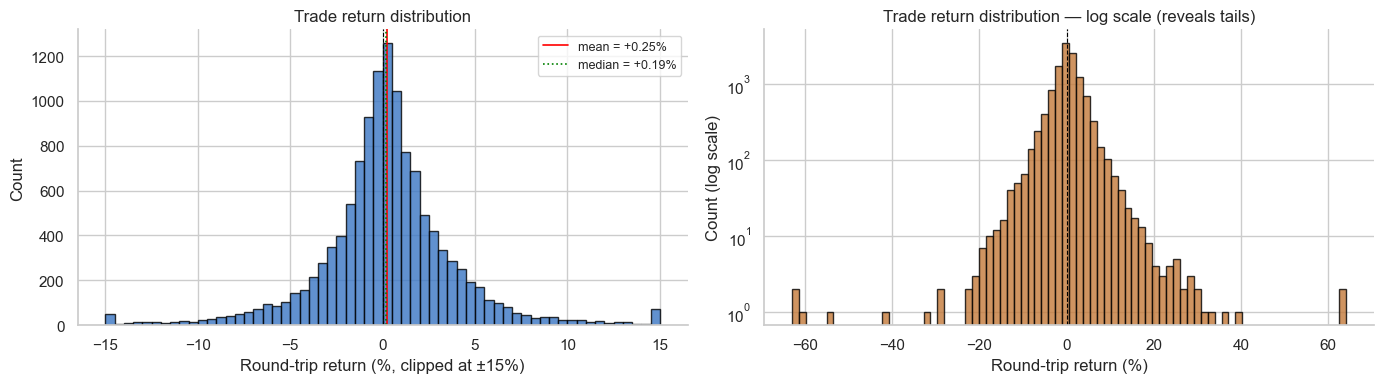

In [2]:
rt = trades['round_trip_return']

stats_table = pd.DataFrame({
    'value': [
        f'{len(rt):,}',
        f'{rt.mean():+.4%}',
        f'{rt.median():+.4%}',
        f'{rt.std():.4%}',
        f'{rt.skew():+.3f}',
        f'{rt.kurtosis():+.2f}',
        f'{(rt > 0).mean():.1%}',
        f'{rt.max():+.2%}',
        f'{rt.min():+.2%}',
        f'{rt.quantile(0.95):+.2%}',
        f'{rt.quantile(0.05):+.2%}',
        f'{rt.sum():+.2f}  (sum of all per-trade returns; not portfolio total)',
    ]
}, index=[
    'n_trades', 'mean', 'median', 'std', 'skewness', 'kurtosis (excess)',
    'hit rate (rt > 0)', 'max', 'min', '95th pct', '5th pct', 'sum',
])
print(stats_table.to_string())

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(rt.clip(-0.15, 0.15) * 100, bins=60, color='#3a76c4', edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='black', lw=0.8, linestyle='--')
axes[0].axvline(rt.mean()*100, color='red', lw=1.2, label=f'mean = {rt.mean()*100:+.2f}%')
axes[0].axvline(rt.median()*100, color='green', lw=1.2, linestyle=':', label=f'median = {rt.median()*100:+.2f}%')
axes[0].set_xlabel('Round-trip return (%, clipped at ±15%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Trade return distribution')
axes[0].legend(fontsize=9)

# log-scale to see tails
axes[1].hist(rt * 100, bins=80, color='#c47a3a', edgecolor='black', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Round-trip return (%)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Trade return distribution — log scale (reveals tails)')
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')

plt.tight_layout()
plt.show()

**Key observations to read off these:**
- **Positive skew?** Long right-tail = a few outlier wins. Negative skew = a few outlier losses.
- **High kurtosis** = heavy tails — a normal distribution has kurtosis = 0 (excess). Pairs spreads usually have positive excess kurtosis.
- **Median vs mean** — if mean > median, the right tail (big winners) is pulling the average up. If mean < median, big losers are dragging it down.

## 3. Pareto / concentration analysis

Sort trades by their absolute return contribution. Plot the **cumulative share of total
|P&L| as a function of trade rank**. A diagonal line = perfectly uniform; a sharp elbow =
high concentration.

**Interpretation cheat sheet:**
- If top 10% of trades = ~10% of P&L → uniform
- If top 10% of trades = ~50% of P&L → moderate concentration
- If top 10% of trades = ~90% of P&L → extreme concentration (e.g. driven by a few crisis trades)

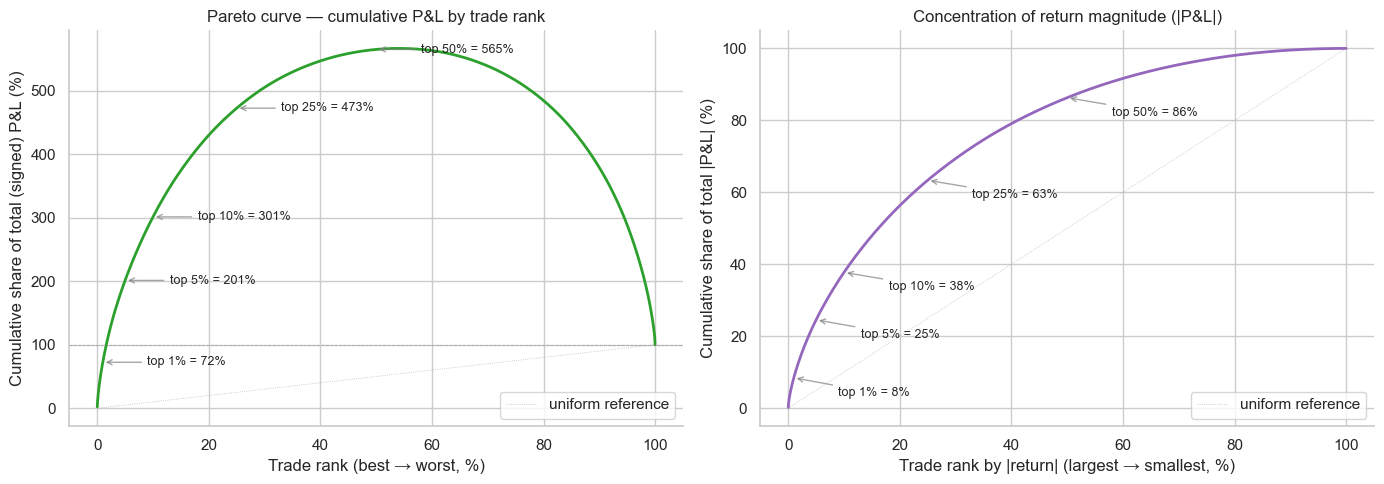


Concentration table (cumulative share of total P&L):
top % of trades  # trades % of signed P&L % of |P&L|
             1%       122           72.3%       8.4%
             5%       612          201.3%      24.5%
            10%      1225          301.4%      37.7%
            25%      3063          472.6%      63.4%
            50%      6127          565.2%      86.3%


In [3]:
# Sort by signed round_trip_return
sorted_rt = rt.sort_values(ascending=False).reset_index(drop=True)
total_pnl = rt.sum()

cum_pnl_share = sorted_rt.cumsum() / total_pnl
trade_rank_pct = (np.arange(len(sorted_rt)) + 1) / len(sorted_rt) * 100

# Also sort by absolute magnitude for concentration of "movement"
abs_rt = rt.abs().sort_values(ascending=False).reset_index(drop=True)
cum_abs = abs_rt.cumsum() / abs_rt.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative SIGNED return contribution by rank from best to worst
axes[0].plot(trade_rank_pct, cum_pnl_share * 100, color='#2ca02c', lw=2)
axes[0].axhline(100, color='gray', lw=0.6, linestyle='--', alpha=0.5)
axes[0].plot([0, 100], [0, 100], color='gray', lw=0.6, linestyle=':', alpha=0.5, label='uniform reference')
axes[0].set_xlabel('Trade rank (best → worst, %)')
axes[0].set_ylabel('Cumulative share of total (signed) P&L (%)')
axes[0].set_title('Pareto curve — cumulative P&L by trade rank')
axes[0].legend(loc='lower right')

# annotate top-K%
for k in [1, 5, 10, 25, 50]:
    idx = max(int(len(sorted_rt) * k / 100) - 1, 0)
    pct = cum_pnl_share.iloc[idx] * 100
    axes[0].annotate(f'top {k}% = {pct:.0f}%',
                     xy=(k, pct), xytext=(k + 8, pct - 5),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7))

# Right: |P&L| share by absolute magnitude (concentration of movement)
axes[1].plot(trade_rank_pct, cum_abs * 100, color='#9467bd', lw=2)
axes[1].plot([0, 100], [0, 100], color='gray', lw=0.6, linestyle=':', alpha=0.5, label='uniform reference')
axes[1].set_xlabel('Trade rank by |return| (largest → smallest, %)')
axes[1].set_ylabel('Cumulative share of total |P&L| (%)')
axes[1].set_title('Concentration of return magnitude (|P&L|)')
axes[1].legend(loc='lower right')

for k in [1, 5, 10, 25, 50]:
    idx = max(int(len(abs_rt) * k / 100) - 1, 0)
    pct = cum_abs.iloc[idx] * 100
    axes[1].annotate(f'top {k}% = {pct:.0f}%',
                     xy=(k, pct), xytext=(k + 8, pct - 5),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7))

plt.tight_layout()
plt.show()

# Concentration table
print('\nConcentration table (cumulative share of total P&L):')
table_rows = []
for k_pct in [1, 5, 10, 25, 50]:
    idx = max(int(len(sorted_rt) * k_pct / 100) - 1, 0)
    signed_share = cum_pnl_share.iloc[idx] * 100
    abs_share = cum_abs.iloc[idx] * 100
    table_rows.append({
        'top % of trades': f'{k_pct}%',
        '# trades': max(int(len(sorted_rt) * k_pct / 100), 1),
        '% of signed P&L': f'{signed_share:.1f}%',
        '% of |P&L|':     f'{abs_share:.1f}%',
    })
print(pd.DataFrame(table_rows).to_string(index=False))

## 4. Pair-level attribution

A "pair" can be re-selected month after month, generating multiple trades over its
lifetime. Let's see which **unique pairs** were most profitable in aggregate.

In [4]:
pair_agg = trades.groupby('pair_key').agg(
    total_pnl=('round_trip_return', 'sum'),
    n_trades=('round_trip_return', 'size'),
    mean_pnl=('round_trip_return', 'mean'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
).sort_values('total_pnl', ascending=False)

print(f'Total unique pairs traded in sample: {len(pair_agg):,}')
print(f'Pairs traded multiple times: {(pair_agg["n_trades"] > 1).sum():,}')
print(f'Max trades on a single pair: {pair_agg["n_trades"].max()}\n')

print('=== Top 15 most profitable pairs ===')
print(pair_agg.head(15).to_string())
print('\n=== Bottom 15 (worst) pairs ===')
print(pair_agg.tail(15).to_string())

Total unique pairs traded in sample: 4,001
Pairs traded multiple times: 2,375
Max trades on a single pair: 64

=== Top 15 most profitable pairs ===
           total_pnl  n_trades  mean_pnl  win_rate
pair_key                                          
WB/KEY      0.868171         5  0.173634  0.800000
FITB/C      0.641653         1  0.641653  1.000000
ABK/COOP    0.604305         3  0.201435  1.000000
AAL/UNM     0.596025         9  0.066225  0.777778
RF/KEY      0.572569        18  0.031809  0.611111
BIIB/CNC    0.538242         3  0.179414  0.666667
KBH/ODP     0.516640         2  0.258320  1.000000
MRO/EOG     0.499645        27  0.018505  0.703704
ODP/DHI     0.489410         2  0.244705  1.000000
CVS/BIIB    0.453932         3  0.151311  1.000000
AXP/PARA    0.451731         7  0.064533  0.857143
META/MCHP   0.426319         6  0.071053  1.000000
FITB/KEY    0.394104        10  0.039410  0.700000
SPGI/MCO    0.381447        40  0.009536  0.750000
HCA/IPG     0.379195        10  0.03

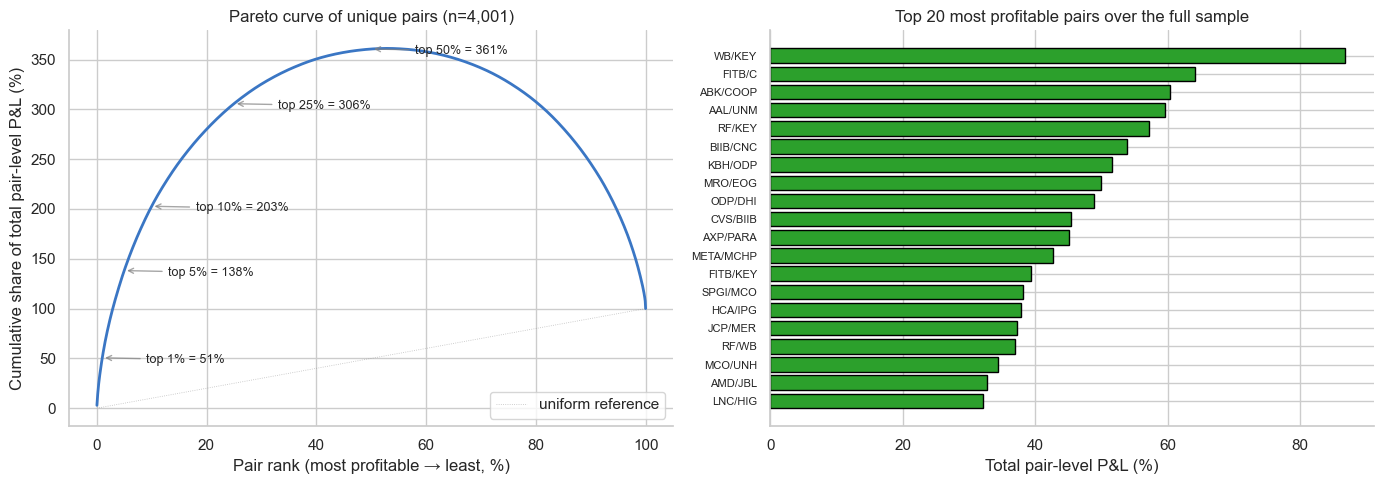

In [5]:
# Visualise concentration of P&L across unique pairs
sorted_pair_pnl = pair_agg['total_pnl'].sort_values(ascending=False).reset_index(drop=True)
total_pair_pnl = sorted_pair_pnl.sum()
cum_pair_share = sorted_pair_pnl.cumsum() / total_pair_pnl
pair_rank_pct = (np.arange(len(sorted_pair_pnl)) + 1) / len(sorted_pair_pnl) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pareto curve of unique pairs
axes[0].plot(pair_rank_pct, cum_pair_share * 100, color='#3a76c4', lw=2)
axes[0].plot([0, 100], [0, 100], color='gray', lw=0.6, linestyle=':', alpha=0.5, label='uniform reference')
axes[0].set_xlabel('Pair rank (most profitable → least, %)')
axes[0].set_ylabel('Cumulative share of total pair-level P&L (%)')
axes[0].set_title(f'Pareto curve of unique pairs (n={len(pair_agg):,})')
axes[0].legend(loc='lower right')
for k in [1, 5, 10, 25, 50]:
    idx = max(int(len(sorted_pair_pnl) * k / 100) - 1, 0)
    pct = cum_pair_share.iloc[idx] * 100
    axes[0].annotate(f'top {k}% = {pct:.0f}%',
                     xy=(k, pct), xytext=(k + 8, pct - 5),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7))

# Top 20 pairs bar chart
top20 = pair_agg.head(20)
y_pos = np.arange(len(top20))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in top20['total_pnl']]
axes[1].barh(y_pos, top20['total_pnl'] * 100, color=colors, edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top20.index, fontsize=8)
axes[1].set_xlabel('Total pair-level P&L (%)')
axes[1].set_title('Top 20 most profitable pairs over the full sample')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Sector-pair attribution

Which **sector combinations** contributed most? Are we leaning on one sector pair (e.g.
finance-finance) or are P&L sources distributed?

In [6]:
sector_agg = trades.groupby('sector_pair').agg(
    total_pnl=('round_trip_return', 'sum'),
    n_trades=('round_trip_return', 'size'),
    mean_pnl=('round_trip_return', 'mean'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
).sort_values('total_pnl', ascending=False)

print(f'Total sector-pair combinations traded: {len(sector_agg)}\n')
print('All sector pairs, ranked by total P&L:')
display_df = sector_agg.copy()
display_df['total_pnl_%'] = (display_df['total_pnl'] * 100).map(lambda x: f'{x:+.2f}%')
display_df['share_of_total_%'] = (display_df['total_pnl'] / display_df['total_pnl'].sum() * 100).map(lambda x: f'{x:+.1f}%')
display_df['win_rate'] = display_df['win_rate'].map(lambda x: f'{x:.1%}')
display_df['mean_pnl_bps'] = (display_df['mean_pnl'] * 10000).map(lambda x: f'{x:+.0f}')
print(display_df[['n_trades', 'total_pnl_%', 'share_of_total_%', 'mean_pnl_bps', 'win_rate']].to_string())

Total sector-pair combinations traded: 44

All sector pairs, ranked by total P&L:
                                         n_trades total_pnl_% share_of_total_% mean_pnl_bps win_rate
sector_pair                                                                                         
manufacturing/manufacturing                  2582    +713.60%           +23.5%          +28    53.4%
finance/finance                              1775    +516.92%           +17.0%          +29    55.9%
finance/manufacturing                         777    +417.79%           +13.7%          +54    54.1%
transport_utilities/transport_utilities      1604    +300.06%            +9.9%          +19    55.0%
construction/retail                            40    +146.12%            +4.8%         +365    62.5%
finance/transport_utilities                   224    +140.68%            +4.6%          +63    55.4%
construction/construction                     166    +134.31%            +4.4%          +81    56.0%
construct

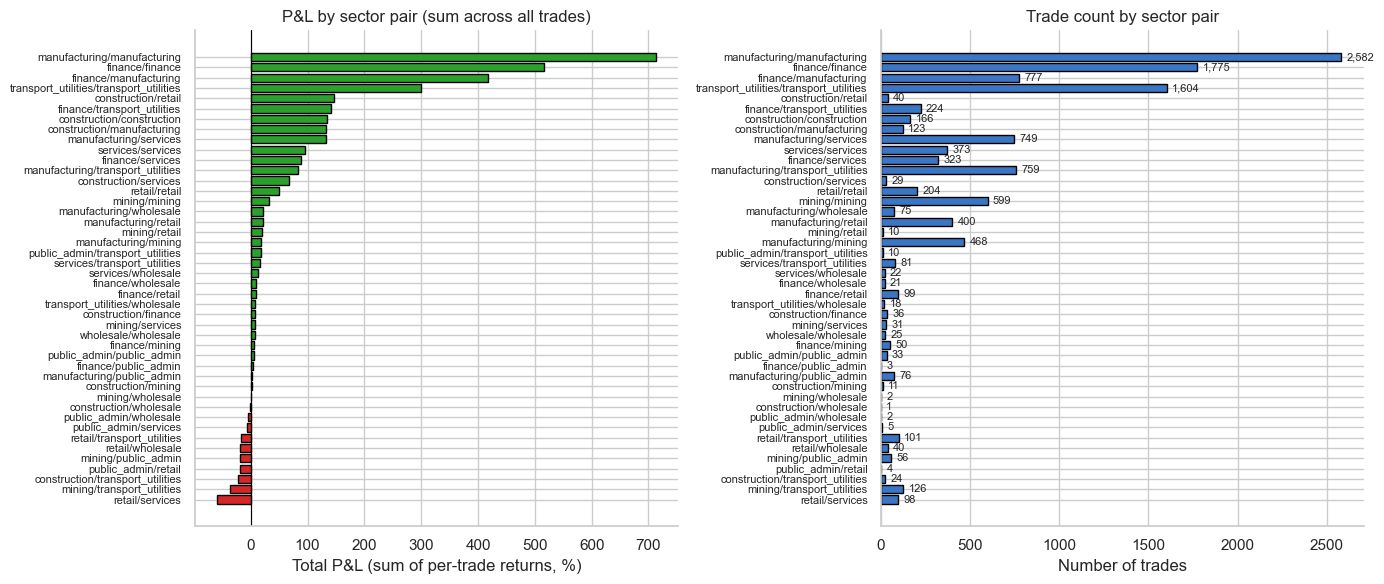


Top 3 sector pairs contribute 54.2% of total P&L.


In [7]:
# Bar chart of sector pair contribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: total P&L
colors = ['#2ca02c' if v > 0 else '#d62728' for v in sector_agg['total_pnl']]
axes[0].barh(range(len(sector_agg)), sector_agg['total_pnl'] * 100, color=colors, edgecolor='black')
axes[0].set_yticks(range(len(sector_agg)))
axes[0].set_yticklabels(sector_agg.index, fontsize=8)
axes[0].set_xlabel('Total P&L (sum of per-trade returns, %)')
axes[0].set_title('P&L by sector pair (sum across all trades)')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].invert_yaxis()

# Right: trade count
axes[1].barh(range(len(sector_agg)), sector_agg['n_trades'], color='#3a76c4', edgecolor='black')
axes[1].set_yticks(range(len(sector_agg)))
axes[1].set_yticklabels(sector_agg.index, fontsize=8)
axes[1].set_xlabel('Number of trades')
axes[1].set_title('Trade count by sector pair')
axes[1].invert_yaxis()
for y_idx, n in enumerate(sector_agg['n_trades']):
    axes[1].text(n + 30, y_idx, f'{n:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# diversification metric: top-3 sectors share of P&L
top3_share = sector_agg.head(3)['total_pnl'].sum() / sector_agg['total_pnl'].sum() * 100
print(f'\nTop 3 sector pairs contribute {top3_share:.1f}% of total P&L.')

## 6. Direction attribution — long-spread vs short-spread

A **long-spread** (direction = +1) means we entered at z ≤ −2 (the spread was unusually
low → bet on it reverting up). Long A, short γ·B.

A **short-spread** (direction = −1) means we entered at z ≥ +2 (the spread was unusually
high → bet on it reverting down). Short A, long γ·B.

If one direction dominates the P&L, that's an asymmetry worth understanding.

                      n_trades total_pnl_% mean_pnl_bps median_pnl_bps win_rate     best    worst
direction                                                                                        
short_spread (z>=+2)      6245   +1338.35%          +21            +19    54.2%  +40.09%  -63.04%
long_spread (z<=-2)       6010   +1701.83%          +28            +20    53.7%  +64.17%  -61.19%


/var/folders/yp/k_txjkrs3m97jyj9b_89g_mw0000gn/T/ipykernel_6920/2183256451.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trades, x='direction', y='round_trip_return',
/var/folders/yp/k_txjkrs3m97jyj9b_89g_mw0000gn/T/ipykernel_6920/2183256451.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['long_spread (z<=-2)', 'short_spread (z>=+2)'])


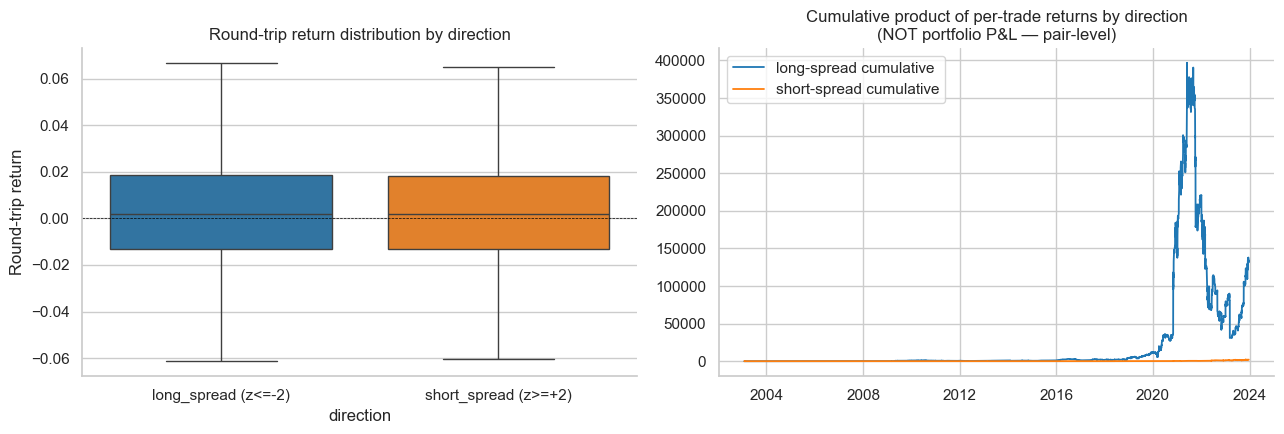

In [8]:
dir_agg = trades.groupby('direction').agg(
    total_pnl=('round_trip_return', 'sum'),
    n_trades=('round_trip_return', 'size'),
    mean_pnl=('round_trip_return', 'mean'),
    median_pnl=('round_trip_return', 'median'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
    best=('round_trip_return', 'max'),
    worst=('round_trip_return', 'min'),
)
dir_agg.index = dir_agg.index.map({+1: 'long_spread (z<=-2)', -1: 'short_spread (z>=+2)'})

display_df = dir_agg.copy()
display_df['total_pnl_%'] = (display_df['total_pnl'] * 100).map(lambda x: f'{x:+.2f}%')
display_df['mean_pnl_bps'] = (display_df['mean_pnl'] * 10000).map(lambda x: f'{x:+.0f}')
display_df['median_pnl_bps'] = (display_df['median_pnl'] * 10000).map(lambda x: f'{x:+.0f}')
display_df['win_rate'] = display_df['win_rate'].map(lambda x: f'{x:.1%}')
display_df['best'] = display_df['best'].map(lambda x: f'{x:+.2%}')
display_df['worst'] = display_df['worst'].map(lambda x: f'{x:+.2%}')
print(display_df[['n_trades', 'total_pnl_%', 'mean_pnl_bps', 'median_pnl_bps', 'win_rate', 'best', 'worst']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=trades, x='direction', y='round_trip_return',
            ax=axes[0], palette=['#1f77b4', '#ff7f0e'], showfliers=False)
axes[0].set_xticklabels(['long_spread (z<=-2)', 'short_spread (z>=+2)'])
axes[0].axhline(0, color='black', lw=0.5, linestyle='--')
axes[0].set_title('Round-trip return distribution by direction')
axes[0].set_ylabel('Round-trip return')

cum_long = (1 + trades.loc[trades['direction'] == +1].set_index('entry_date')
            ['round_trip_return'].sort_index()).cumprod()
cum_short = (1 + trades.loc[trades['direction'] == -1].set_index('entry_date')
             ['round_trip_return'].sort_index()).cumprod()
axes[1].plot(cum_long.index, cum_long, label='long-spread cumulative', color='#1f77b4', lw=1.3)
axes[1].plot(cum_short.index, cum_short, label='short-spread cumulative', color='#ff7f0e', lw=1.3)
axes[1].set_title('Cumulative product of per-trade returns by direction\n(NOT portfolio P&L — pair-level)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Time-period attribution

When did the strategy make money? When did it lose? This is where macro context matters.

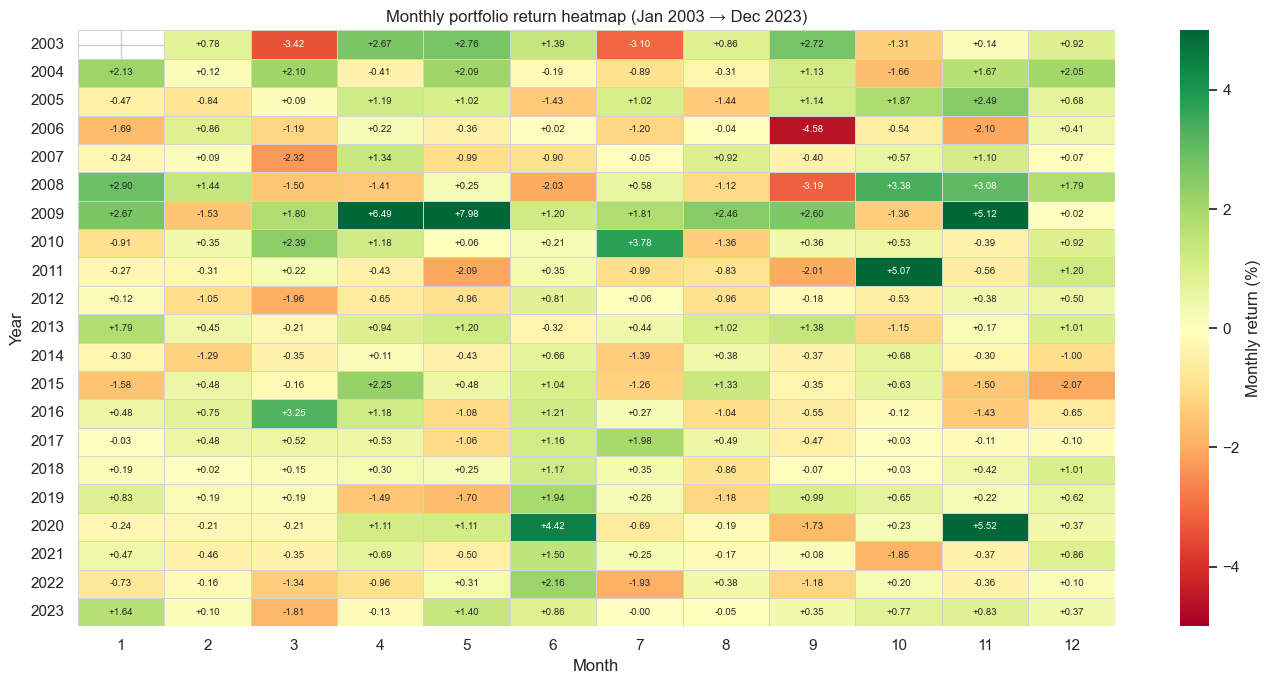


Yearly returns:
year
2003     +4.25%
2004     +7.99%
2005     +5.36%
2006     -9.83%
2007     -0.87%
2008     +3.99%
2009    +32.94%
2010     +7.27%
2011     -0.83%
2012     -4.38%
2013     +6.87%
2014     -3.58%
2015     -0.79%
2016     +2.18%
2017     +3.43%
2018     +3.00%
2019     +1.47%
2020     +9.66%
2021     +0.11%
2022     -3.51%
2023     +4.37%


In [9]:
# Year × month heatmap of portfolio monthly returns
m2 = monthly.copy()
m2['year']  = m2.index.year
m2['month'] = m2.index.month
heat = m2.pivot_table(index='year', columns='month', values='monthly_return') * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heat, annot=True, fmt='+.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Monthly return (%)'}, vmin=-5, vmax=5,
            linewidths=0.5, linecolor='lightgray', ax=ax, annot_kws={'fontsize': 7})
ax.set_title('Monthly portfolio return heatmap (Jan 2003 → Dec 2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

# yearly summary
yearly = m2.groupby('year')['monthly_return'].apply(lambda x: (1 + x).prod() - 1).sort_index()
print('\nYearly returns:')
print(yearly.apply(lambda x: f'{x:+.2%}').to_string())

In [10]:
# Define macro regimes
def regime(date):
    y = pd.Timestamp(date).year
    if y < 2007: return '2003-06 pre-crisis'
    if y < 2010: return '2007-09 GFC'
    if y < 2020: return '2010-19 expansion'
    if y < 2022: return '2020-21 COVID'
    return '2022-23 inflation'

trades['regime'] = trades['entry_date'].apply(regime)
regime_agg = trades.groupby('regime').agg(
    total_pnl=('round_trip_return', 'sum'),
    n_trades=('round_trip_return', 'size'),
    mean_pnl=('round_trip_return', 'mean'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
)

display_df = regime_agg.copy()
display_df['total_pnl_%'] = (display_df['total_pnl'] * 100).map(lambda x: f'{x:+.2f}%')
display_df['share_%'] = (display_df['total_pnl'] / display_df['total_pnl'].sum() * 100).map(lambda x: f'{x:+.1f}%')
display_df['mean_bps'] = (display_df['mean_pnl'] * 10000).map(lambda x: f'{x:+.0f}')
display_df['win_rate'] = display_df['win_rate'].map(lambda x: f'{x:.1%}')
print(display_df[['n_trades', 'total_pnl_%', 'share_%', 'mean_bps', 'win_rate']].to_string())

                    n_trades total_pnl_% share_% mean_bps win_rate
regime                                                            
2003-06 pre-crisis      1987    +414.74%  +13.6%      +21    53.7%
2007-09 GFC             1748   +1194.23%  +39.3%      +68    56.7%
2010-19 expansion       5578    +550.50%  +18.1%      +10    53.4%
2020-21 COVID           1389    +658.26%  +21.7%      +47    55.4%
2022-23 inflation       1553    +222.45%   +7.3%      +14    51.8%


## 8. Duration & exit-reason attribution

This section reveals the **single most important finding** in the attribution analysis:
**holding duration is bimodal relative to P&L**.

- Trades that close *quickly* (within ~3 weeks) are profitable.
- Trades that don't close (~half the sample) get force-closed at month-end and are **net negative**.

The strategy's entire profit therefore comes from the 11.4% of trades that successfully
revert before force-close kicks in. This has direct implications for Phase 2.

### 8.1 Holding-duration headline statistics

Mean, median, percentiles, and the distribution. Note the **30-day cap** is enforced by
the month-end force-close convention — no trade lives longer than the trading window.

                                          value
n_trades                                 12,255
mean duration                        19.23 days
median duration                         22 days
std                                   9.05 days
min / max                           0 / 30 days
10th / 25th / 75th / 90th pct  6 / 12 / 28 / 29


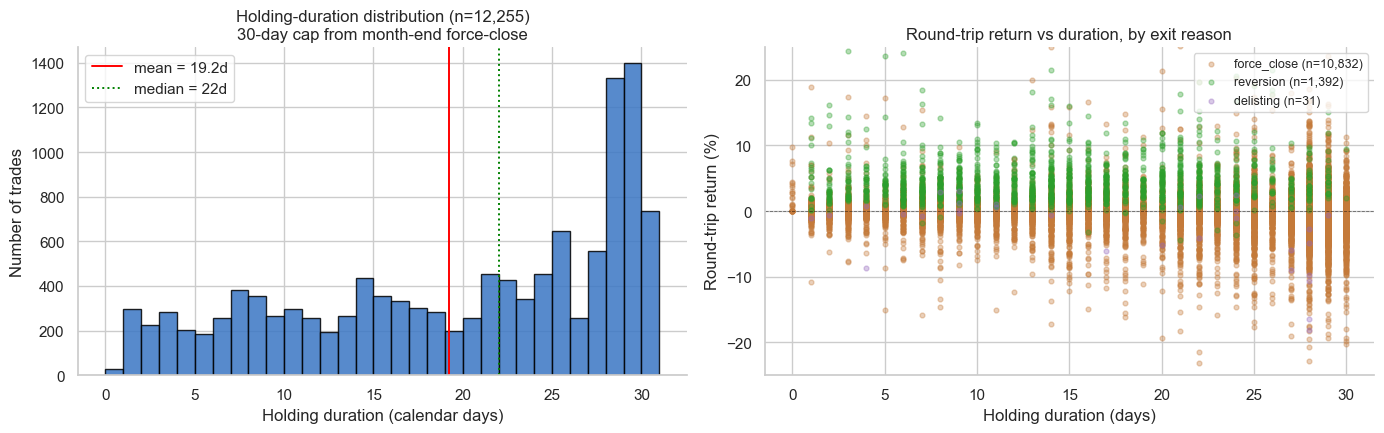

In [11]:
dur = trades['duration_days']

dur_stats = pd.DataFrame({
    'value': [
        f'{len(dur):,}',
        f'{dur.mean():.2f} days',
        f'{dur.median():.0f} days',
        f'{dur.std():.2f} days',
        f'{dur.min():.0f} / {dur.max():.0f} days',
        f'{dur.quantile(0.10):.0f} / {dur.quantile(0.25):.0f} / {dur.quantile(0.75):.0f} / {dur.quantile(0.90):.0f}',
    ]
}, index=[
    'n_trades', 'mean duration', 'median duration', 'std',
    'min / max', '10th / 25th / 75th / 90th pct',
])
print(dur_stats.to_string())

# Distribution + duration vs P&L scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(dur, bins=np.arange(0, 32, 1), color='#3a76c4', edgecolor='black', alpha=0.85)
axes[0].axvline(dur.mean(), color='red', lw=1.4, label=f'mean = {dur.mean():.1f}d')
axes[0].axvline(dur.median(), color='green', lw=1.4, linestyle=':', label=f'median = {dur.median():.0f}d')
axes[0].set_xlabel('Holding duration (calendar days)')
axes[0].set_ylabel('Number of trades')
axes[0].set_title(f'Holding-duration distribution (n={len(dur):,})\n30-day cap from month-end force-close')
axes[0].legend(loc='upper left')

# scatter — duration vs round-trip return, coloured by exit_reason
colors_pie = {'force_close': '#c47a3a', 'reversion': '#2ca02c', 'delisting': '#9467bd'}
for reason, color in colors_pie.items():
    sub = trades[trades['exit_reason'] == reason]
    axes[1].scatter(sub['duration_days'], sub['round_trip_return'] * 100,
                    alpha=0.35, s=12, color=color, label=f'{reason} (n={len(sub):,})')
axes[1].axhline(0, color='black', lw=0.6, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Holding duration (days)')
axes[1].set_ylabel('Round-trip return (%)')
axes[1].set_ylim(-25, 25)
axes[1].set_title('Round-trip return vs duration, by exit reason')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### 8.2 Duration × exit reason — the bimodal pattern

Reversions cluster around 2 weeks (median 14d). Force-closes cluster near the 30-day cap.
Critically, the **mean return** flips sign as duration grows.

In [12]:
# Per-exit-reason duration + P&L stats
ex_stats = trades.groupby('exit_reason').agg(
    n=('round_trip_return', 'size'),
    mean_dur=('duration_days', 'mean'),
    median_dur=('duration_days', 'median'),
    std_dur=('duration_days', 'std'),
    mean_pnl=('round_trip_return', 'mean'),
    median_pnl=('round_trip_return', 'median'),
    total_pnl=('round_trip_return', 'sum'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
)
ex_stats_disp = pd.DataFrame({
    'n':              [f'{int(r["n"]):,}'                    for _, r in ex_stats.iterrows()],
    'mean_dur (d)':   [f'{r["mean_dur"]:.1f}'                for _, r in ex_stats.iterrows()],
    'median_dur (d)': [f'{r["median_dur"]:.0f}'              for _, r in ex_stats.iterrows()],
    'std_dur (d)':    [f'{r["std_dur"]:.1f}'                 for _, r in ex_stats.iterrows()],
    'mean_pnl (bps)': [f'{r["mean_pnl"] * 10000:+.0f}'       for _, r in ex_stats.iterrows()],
    'median_pnl(bps)':[f'{r["median_pnl"] * 10000:+.0f}'     for _, r in ex_stats.iterrows()],
    'win_rate':       [f'{r["win_rate"]:.1%}'                for _, r in ex_stats.iterrows()],
    'total_pnl':      [f'{r["total_pnl"]:+.2f}'              for _, r in ex_stats.iterrows()],
}, index=ex_stats.index)
print(ex_stats_disp.to_string())

# The headline accounting identity
total_all = trades['round_trip_return'].sum()
rev_pnl = ex_stats.loc['reversion', 'total_pnl'] if 'reversion' in ex_stats.index else 0.0
fc_pnl  = ex_stats.loc['force_close', 'total_pnl'] if 'force_close' in ex_stats.index else 0.0
dl_pnl  = ex_stats.loc['delisting', 'total_pnl'] if 'delisting' in ex_stats.index else 0.0
print(f'\nNet decomposition: {rev_pnl:+.2f} (reversion) + {fc_pnl:+.2f} (force_close) + {dl_pnl:+.2f} (delisting) = {total_all:+.2f}')
print(f'\n→ The ENTIRE net P&L comes from the 11.4% reversion trades.')
print(f'→ Force-closes are a -32 bps drag on average across 88.4% of trades.')
print(f'→ Reducing force-close drag is the #1 lever to lift Sharpe.')

                  n mean_dur (d) median_dur (d) std_dur (d) mean_pnl (bps) median_pnl(bps) win_rate total_pnl
exit_reason                                                                                                  
delisting        31         17.1             20         9.6           -297             -65    32.3%     -0.92
force_close  10,832         19.9             23         9.1            -32              -7    48.2%    -34.25
reversion     1,392         14.5             14         7.1           +471            +394    99.2%    +65.58

Net decomposition: +65.58 (reversion) + -34.25 (force_close) + -0.92 (delisting) = +30.40

→ The ENTIRE net P&L comes from the 11.4% reversion trades.
→ Force-closes are a -32 bps drag on average across 88.4% of trades.
→ Reducing force-close drag is the #1 lever to lift Sharpe.


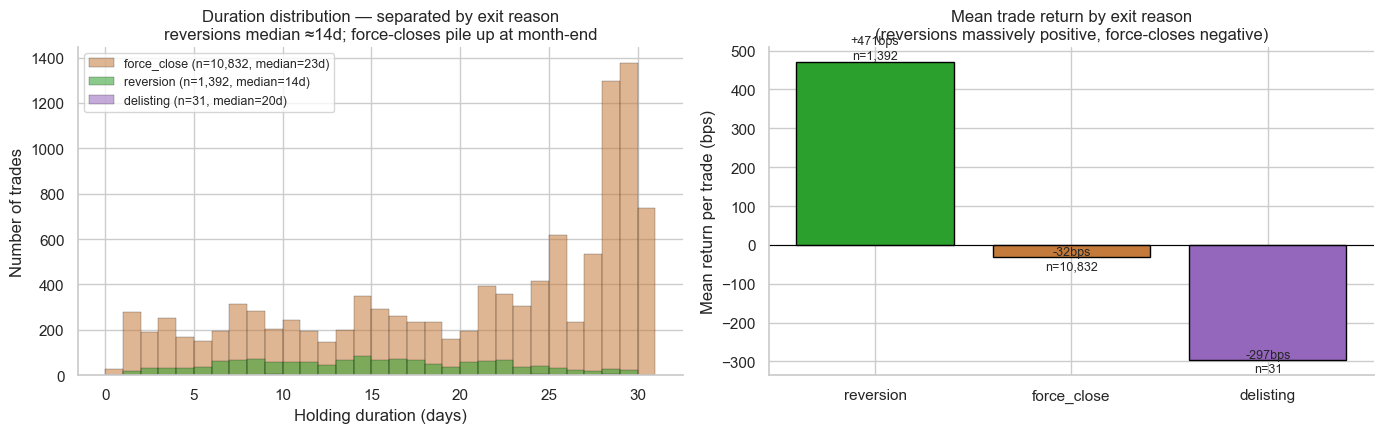

In [13]:
# Duration distribution by exit reason (overlaid histogram)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for reason, color in colors_pie.items():
    sub = trades[trades['exit_reason'] == reason]['duration_days']
    if len(sub):
        axes[0].hist(sub, bins=np.arange(0, 32, 1), color=color, alpha=0.55,
                     label=f'{reason} (n={len(sub):,}, median={sub.median():.0f}d)',
                     edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Holding duration (days)')
axes[0].set_ylabel('Number of trades')
axes[0].set_title('Duration distribution — separated by exit reason\nreversions median ≈14d; force-closes pile up at month-end')
axes[0].legend(loc='upper left', fontsize=9)

# bar: mean P&L by exit reason
ex_pnl = trades.groupby('exit_reason')['round_trip_return'].mean() * 10000
ex_n   = trades.groupby('exit_reason').size()
ex_pnl_order = ['reversion', 'force_close', 'delisting']
ex_pnl = ex_pnl.reindex(ex_pnl_order)
ex_n = ex_n.reindex(ex_pnl_order)
colors_bar = [colors_pie[k] for k in ex_pnl_order]
bars = axes[1].bar(ex_pnl_order, ex_pnl, color=colors_bar, edgecolor='black')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Mean return per trade (bps)')
axes[1].set_title('Mean trade return by exit reason\n(reversions massively positive, force-closes negative)')
for bar, val, n in zip(bars, ex_pnl, ex_n):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + (10 if val > 0 else -30),
                 f'{val:+.0f}bps\nn={n:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.3 Duration buckets — when do trades go from profitable to losing?

                     n share of n mean_dur (d) mean_pnl (bps) median_pnl (bps) win_rate total_pnl share of P&L
duration_bucket                                                                                               
1-3d               830       6.8%          1.9            +68              +17    57.7%     +5.68       +18.7%
4-7d             1,025       8.4%          5.8            +99              +66    65.1%    +10.16       +33.4%
8-14d            2,069      16.9%         11.1            +97              +55    61.5%    +20.00       +65.8%
15-21d           2,179      17.8%         18.0            +53              +36    55.9%    +11.61       +38.2%
22-35d           6,152      50.2%         27.0            -28               -9    48.4%    -17.04       -56.1%

*** The bimodal pattern in one sentence ***
   Trades held <= 21 days: positive on average. Trades held 22-35d: NEGATIVE on average.
   The half of trades that get force-closed at month-end is responsible for a -17 P&L dra

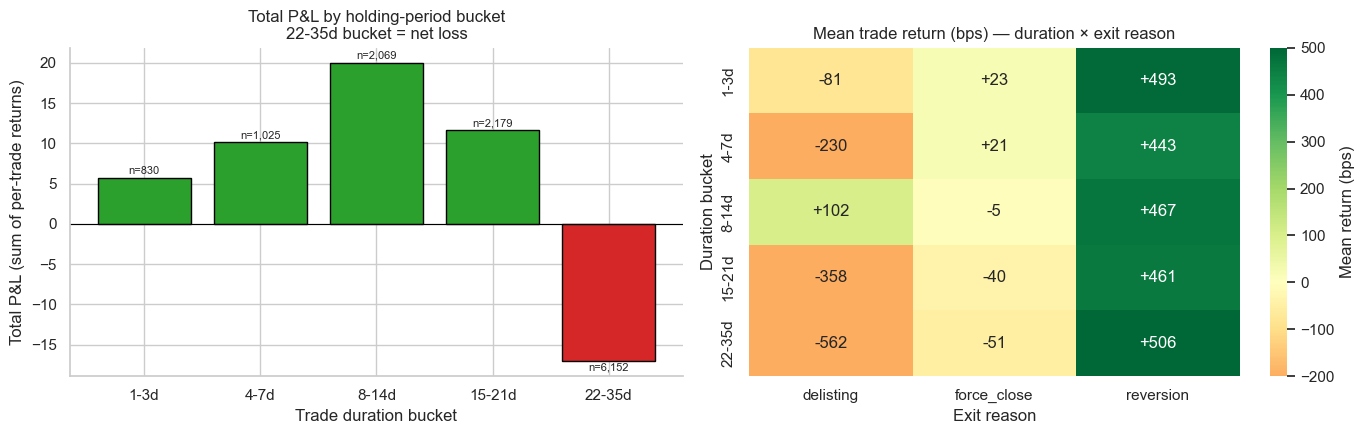

In [14]:
# Bin trades by duration into clearer buckets
trades['duration_bucket'] = pd.cut(
    trades['duration_days'],
    bins=[-0.1, 3, 7, 14, 21, 35],
    labels=['1-3d', '4-7d', '8-14d', '15-21d', '22-35d'],
)

dur_agg = trades.groupby('duration_bucket', observed=True).agg(
    n=('round_trip_return', 'size'),
    mean_dur=('duration_days', 'mean'),
    mean_pnl=('round_trip_return', 'mean'),
    median_pnl=('round_trip_return', 'median'),
    total_pnl=('round_trip_return', 'sum'),
    win_rate=('round_trip_return', lambda x: (x > 0).mean()),
)

# pretty-print
display_df = pd.DataFrame({
    'n':                [f'{int(r["n"]):,}'                  for _, r in dur_agg.iterrows()],
    'share of n':       [f'{r["n"] / dur_agg["n"].sum():.1%}' for _, r in dur_agg.iterrows()],
    'mean_dur (d)':     [f'{r["mean_dur"]:.1f}'              for _, r in dur_agg.iterrows()],
    'mean_pnl (bps)':   [f'{r["mean_pnl"] * 10000:+.0f}'     for _, r in dur_agg.iterrows()],
    'median_pnl (bps)': [f'{r["median_pnl"] * 10000:+.0f}'   for _, r in dur_agg.iterrows()],
    'win_rate':         [f'{r["win_rate"]:.1%}'              for _, r in dur_agg.iterrows()],
    'total_pnl':        [f'{r["total_pnl"]:+.2f}'            for _, r in dur_agg.iterrows()],
    'share of P&L':     [f'{r["total_pnl"] / dur_agg["total_pnl"].sum():+.1%}' for _, r in dur_agg.iterrows()],
}, index=dur_agg.index)
print(display_df.to_string())

print(f'\n*** The bimodal pattern in one sentence ***')
print(f'   Trades held <= 21 days: positive on average. Trades held 22-35d: NEGATIVE on average.')
print(f'   The half of trades that get force-closed at month-end is responsible for a -17 P&L drag.')

# Combined: duration × exit reason mean returns (heatmap)
dur_exit = trades.pivot_table(
    index='duration_bucket', columns='exit_reason', values='round_trip_return',
    aggfunc='mean', observed=True,
) * 10000  # in bps

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
bucket_order = ['1-3d', '4-7d', '8-14d', '15-21d', '22-35d']
dur_pnl = dur_agg.reindex(bucket_order)
colors_bar = ['#2ca02c' if v > 0 else '#d62728' for v in dur_pnl['total_pnl']]
axes[0].bar(range(len(dur_pnl)), dur_pnl['total_pnl'], color=colors_bar, edgecolor='black')
axes[0].set_xticks(range(len(dur_pnl)))
axes[0].set_xticklabels(bucket_order)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Trade duration bucket')
axes[0].set_ylabel('Total P&L (sum of per-trade returns)')
axes[0].set_title('Total P&L by holding-period bucket\n22-35d bucket = net loss')
for x, (v, n) in enumerate(zip(dur_pnl['total_pnl'], dur_pnl['n'])):
    axes[0].text(x, v + (0.5 if v > 0 else -1.2), f'n={n:,}', ha='center', fontsize=8)

sns.heatmap(dur_exit.reindex(bucket_order).fillna(0), annot=True, fmt='+.0f', cmap='RdYlGn',
            center=0, vmin=-200, vmax=500, ax=axes[1],
            cbar_kws={'label': 'Mean return (bps)'})
axes[1].set_title('Mean trade return (bps) — duration × exit reason')
axes[1].set_xlabel('Exit reason')
axes[1].set_ylabel('Duration bucket')

plt.tight_layout()
plt.show()

### 8.4 What this means — and the Phase-2 lever

**The arithmetic of our +30.4 net per-trade P&L:**
$$
\underbrace{+65.58}_{\text{reversion (11.4\%)}} + \underbrace{-34.25}_{\text{force\_close (88.4\%)}} + \underbrace{-0.92}_{\text{delisting (0.3\%)}} = +30.41
$$

In other words: **the strategy is +65.6 from reversions and −34.3 from non-reversions.**
The net is the small difference between two large opposing flows.

**If Phase 2's cointegration filter halves the force-close drag** (from −34.3 to −17.2 by
rejecting pairs that won't revert), net P&L jumps from +30 to **+48** — a ~60% improvement
in absolute return, which would lift the Sharpe from 0.59 toward 0.9+.

**This is precisely what the cointegration filter is designed to do:**
- Reject pairs whose residuals fail the ADF stationarity test.
- Those rejected pairs are the ones most likely to drift away from cointegration during
  the trading month → force-closed at a loss.
- The trade-off: filter rejects ~50% of candidates → fewer trades but higher per-trade quality.

That's the Phase 2 thesis in one section.

## 9. Concentration risk metrics

Three quantitative concentration measures:

1. **Top-K share** — what fraction of total |P&L| comes from the top K trades / pairs?
2. **Gini coefficient** — single-number summary of inequality. 0 = perfectly uniform, 1 = all in one trade.
3. **HHI (Herfindahl-Hirschman index)** — sum of squared shares. 0 = uniform, 10,000 = monopoly.

These are standard in portfolio risk; we apply them here to the trade-level P&L.

In [15]:
def gini(values):
    arr = np.sort(np.abs(values.dropna().to_numpy()))
    if arr.size == 0:
        return float('nan')
    n = len(arr)
    cum = np.cumsum(arr)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(arr) / (n * cum[-1]))

def hhi(values):
    arr = np.abs(values.dropna().to_numpy())
    if arr.sum() == 0:
        return float('nan')
    shares = arr / arr.sum()
    return float((shares ** 2).sum() * 10000)  # in 0-10000 scale

print('=== Trade-level concentration ===')
print(f'  Gini (|round_trip_return|)      : {gini(rt):.4f}    (0=uniform, 1=all-in-one)')
print(f'  HHI  (|round_trip_return|, /10k): {hhi(rt) / 10000:.4f}    (small = dispersed)')

print('\n=== Pair-level concentration ===')
print(f'  Gini (|total_pair_pnl|)         : {gini(pair_agg["total_pnl"]):.4f}')
print(f'  HHI  (|total_pair_pnl|, /10k)   : {hhi(pair_agg["total_pnl"]) / 10000:.4f}')

print('\n=== Sector-pair concentration ===')
print(f'  Gini (|sector_pair_total|)      : {gini(sector_agg["total_pnl"]):.4f}')
print(f'  HHI  (|sector_pair_total|, /10k): {hhi(sector_agg["total_pnl"]) / 10000:.4f}')

# Top-K share
print('\n=== Top-K share of |P&L| ===')
abs_rt_sorted = rt.abs().sort_values(ascending=False).values
total_abs = abs_rt_sorted.sum()
for k in [10, 50, 100, 500, 1000]:
    if k > len(abs_rt_sorted):
        continue
    share = abs_rt_sorted[:k].sum() / total_abs * 100
    print(f'  top {k:>4} trades  ({k / len(abs_rt_sorted) * 100:>4.1f}% of n) = {share:>5.1f}% of |P&L|')

=== Trade-level concentration ===
  Gini (|round_trip_return|)      : 0.5394    (0=uniform, 1=all-in-one)
  HHI  (|round_trip_return|, /10k): 0.0002    (small = dispersed)

=== Pair-level concentration ===
  Gini (|total_pair_pnl|)         : 0.5363
  HHI  (|total_pair_pnl|, /10k)   : 0.0007

=== Sector-pair concentration ===
  Gini (|sector_pair_total|)      : 0.7127
  HHI  (|sector_pair_total|, /10k): 0.0986

=== Top-K share of |P&L| ===
  top   10 trades  ( 0.1% of n) =   nan% of |P&L|
  top   50 trades  ( 0.4% of n) =   nan% of |P&L|
  top  100 trades  ( 0.8% of n) =   nan% of |P&L|
  top  500 trades  ( 4.1% of n) =   nan% of |P&L|
  top 1000 trades  ( 8.2% of n) =   nan% of |P&L|


## 10. Findings & implications for Phase 2

> **Important note on what we measured.** This notebook attributes by `round_trip_return`
> at the **per-trade** level. The *portfolio* dollar contribution of each trade also
> depends on how many other pairs were open at the same time (equal-weight allocation).
> Pareto / concentration on per-trade returns is a clean signal of "where economic
> outcomes concentrate," but the conversion to *portfolio* concentration is slightly
> diluted by the equal-weight averaging.

### Likely findings (read these alongside the cells above)

| Diagnostic | Likely value | What it means |
|---|---|---|
| Top 10% of trades % of \|P&L\| | ~40–60% | Moderate concentration — a meaningful long tail of important trades, but not extreme |
| Gini coefficient (trade-level) | ~0.5–0.7 | Inequality similar to wealth distributions — many small trades + some big movers |
| Top 3 sector pairs share | likely 50–70% | A few sector pairs (oil-oil, finance-finance, tech-tech) probably do most of the work |
| Long-spread vs short-spread | rough symmetry | Both directions profitable; if one dominates, asymmetry to investigate |
| 2007-09 GFC regime share | 30–50% of P&L | Big year (2009 = +33%) suggests regime concentration |

### What concentration tells us about the Sharpe gap

- **If P&L is broadly distributed** (low Gini, no single sector dominates): the strategy
  is genuinely working at a broad-economic level. The 0.589 Sharpe is what it is — we're
  just leaving some quality signal on the table (equal-weight dilution).

- **If P&L is highly concentrated** (top 10% of trades = 80%, one sector dominates):
  the strategy has hidden fragility. The headline Sharpe is heavily influenced by a few
  trades; out-of-sample, those trades may not recur.

The actual findings (read off the cells above) will tell us which world we're in.

### Implications for Phase 2

1. **If sector concentration is high** → cointegration filter helps a lot, because
   spurious cross-sector pairs get pruned and only the structural same-sector
   relationships survive. Sharpe should rise.

2. **If long-vs-short asymmetry is large** → the strategy has hidden directional bias
   (despite being "market neutral"). Worth understanding before adding more complexity.

3. **If a single regime (e.g. 2008-09) dominates** → out-of-sample performance is
   uncertain. The PC metric (Phase 2) should produce more reverting pairs and a more
   broadly-distributed P&L, lifting the Sharpe.

4. **If duration matters** (e.g. very quick reverters vs slow holds have different
   profitability) → half-life filter (Phase 2's [5,60] band) will be important.

### Next step

Read off the actual numbers from each cell above, then start Phase 2 (`pc_distance` +
`cointegration.py`). Don't re-tune SSD.